In [1]:
# Project data exploration
import os
os.environ["OPENBLAS_NUM_THREADS"] = "1"
#scanpy workflow via
#https://nbisweden.github.io/workshop-scRNAseq/archive/2025/labs/scanpy/scanpy_01_qc.html

In [2]:
# Install required packages
!{sys.executable} -m pip install numpy pandas scipy scanpy matplotlib scikit-learn

/bin/bash: line 1: {sys.executable}: command not found


In [3]:
# Install required packages
%pip install gtfparse

Note: you may need to restart the kernel to use updated packages.


In [4]:
# import packages 
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import os
import scipy.sparse as sp
import h5py
import anndata as ad
from gtfparse import read_gtf

In [5]:
# Check the package versions
import importlib
print("Package versions:")
for package_name in ["numpy", "pandas", "scanpy", "matplotlib", "seaborn", "scipy", "anndata"]:
    print(f"- {package_name}: {importlib.metadata.version(package_name)}")

Package versions:
- numpy: 2.5.2
- pandas: 3.0.5
- scanpy: 1.12.3
- matplotlib: 3.11.1
- seaborn: 0.13.2
- scipy: 1.18.1
- anndata: 0.13.2


In [6]:
#Load the data
data_dir = "../data/frangieh"
adata = sc.read_h5ad(f"{data_dir}/rna.h5ad")

In [7]:
#Print the data
print(adata)

AnnData object with n_obs × n_vars = 218331 × 23712
    obs: 'library_preparation_protocol', 'perturbation_2', 'MOI', 'sgRNA', 'UMI_count', 'guide_id', 'perturbation', 'tissue_type', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'perturbation_type_2', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo'
    var: 'ensembl_id', 'ncounts', 'ncells'
    layers: None (.X)


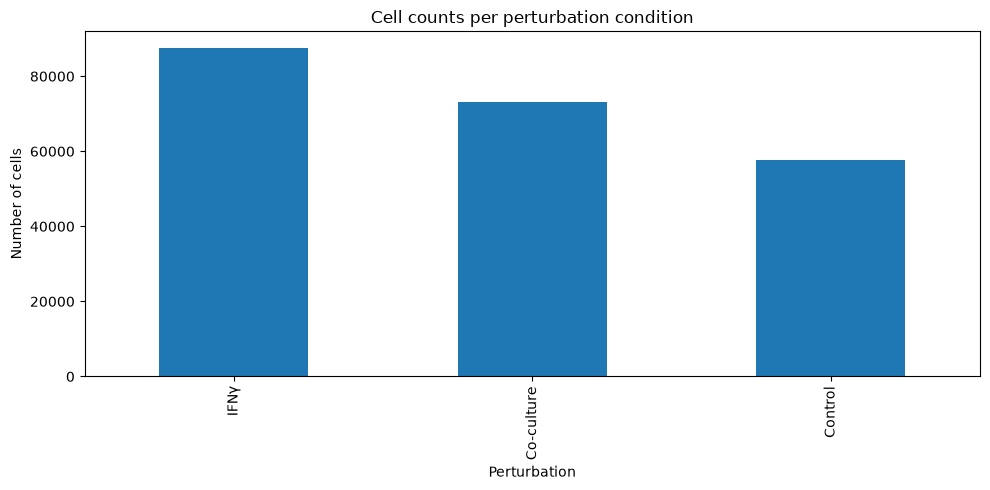

In [8]:
# Explore the columns 
# perturbation_2 represents the condition
# Count cells per perturbation
counts = adata.obs["perturbation_2"].value_counts()
# Plot
plt.figure(figsize=(10, 5))
counts.plot(kind="bar")
plt.xlabel("Perturbation")
plt.ylabel("Number of cells")
plt.title("Cell counts per perturbation condition")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [9]:
# Rename the column perturbation_2 to condition
adata.obs.rename({"perturbation_2": "condition"}, axis=1, inplace=True)

In [15]:
# Data exploration
adata.shape
# Cell numbers across 3 conditions
cell_counts = adata.obs["condition"].value_counts().sort_index()
for perturbation, count in cell_counts.items():
    print(f"{perturbation}: {count} cells")

Co-culture: 73114 cells
Control: 57627 cells
IFNγ: 87590 cells


In [16]:
# QC steps via scanpy workflow
# mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

In [17]:
# Calculate QC metrics for mitochondrial, ribosomal, and hemoglobin genes
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)

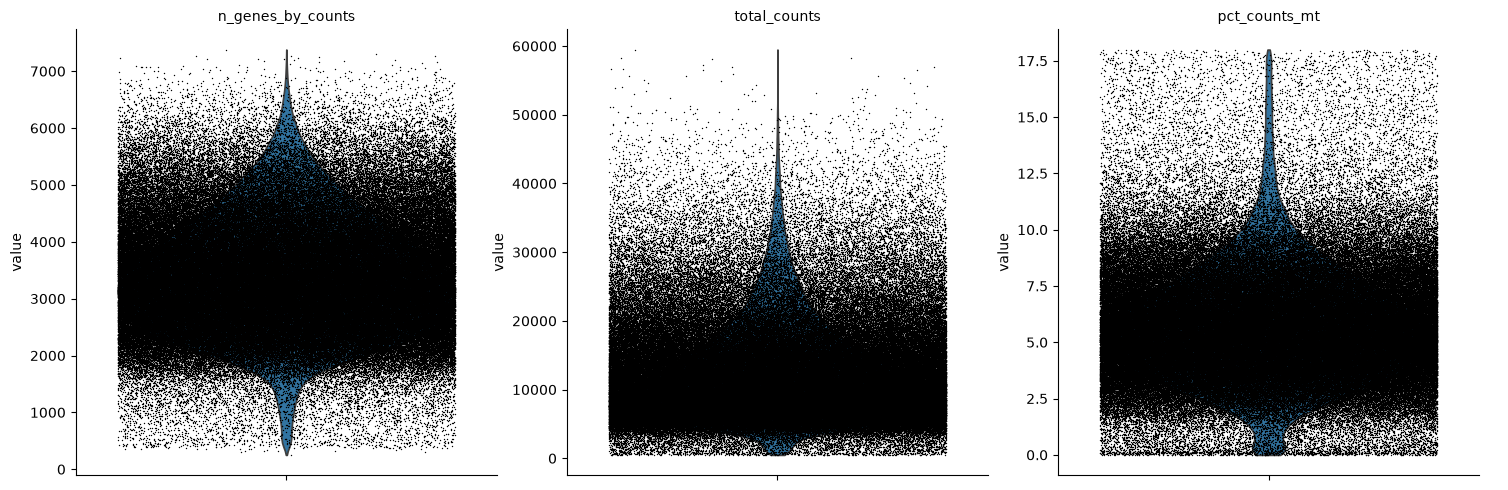

In [18]:
# Visualize the distribution of key QC metrics
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

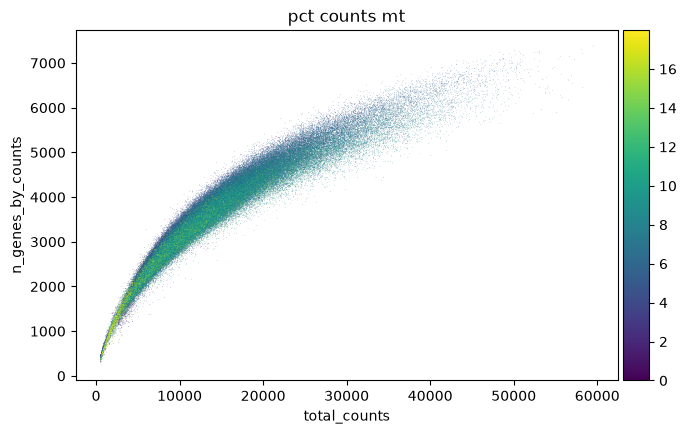

In [19]:
# Visualize counts vs. detected genes, colored by mitochondrial percentage
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [20]:
# Filter cells out that express less then 100 genes and genes that are expressed less then 3 cells
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

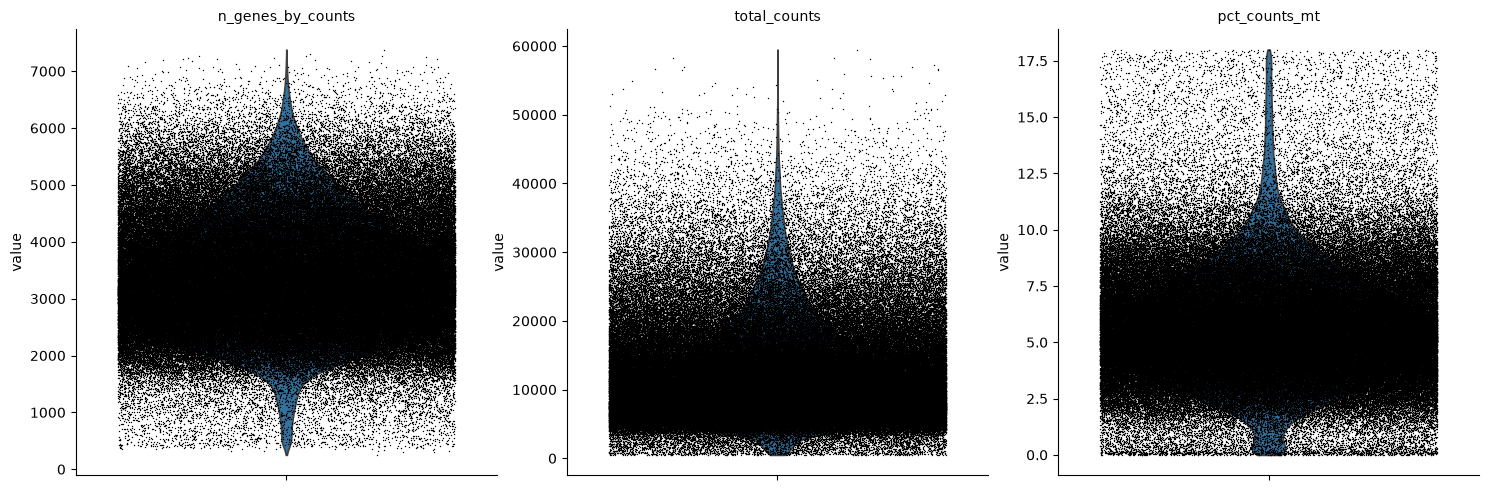

In [21]:
# Visualize the qc metrics after filtering the cells and the genes
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

In [22]:
# Shape of adata after filtering
adata.shape

(218331, 23711)

In [23]:
#Remove cells with high mitochondrial counts
adata = adata[adata.obs.pct_counts_mt < 15]

In [24]:
# Print the shape of the data
adata.shape 

(216508, 23711)

In [25]:
# Save the data after mito filtering and cell an genes filtering
adata_qc_1 = adata.copy()
adata_qc_1.write("../data/frangieh/adata_qc1.h5ad")

In [26]:
#Load the data
adata = sc.read_h5ad("../data/frangieh/adata_qc1.h5ad")

In [27]:
# Remove cells with more than 40,000 total counts
adata = adata[adata.obs.total_counts < 40000]

In [28]:
#Print the shape of the data after filtering
adata.shape 

(215364, 23711)

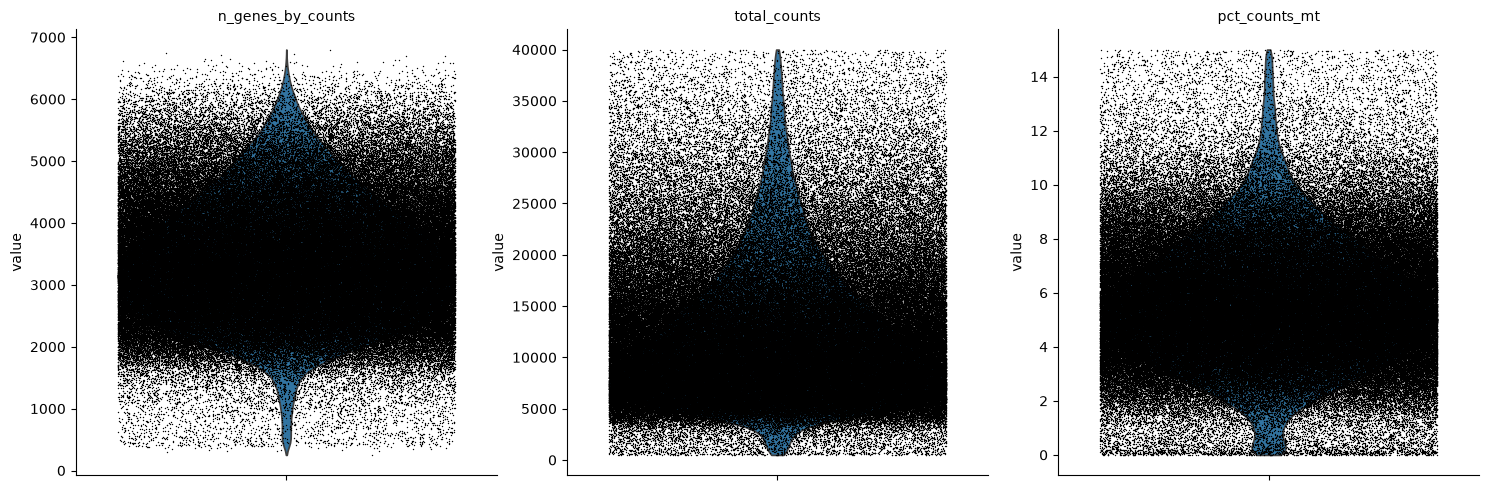

In [29]:
# Visualize QC metrics after total count filtering
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

In [30]:
# Remove cells with fewer than 200 total counts
sc.pp.filter_cells(adata, min_counts=200)

/home/ubuntu/miniforge/envs/denbi/lib/python3.14/site-packages/scanpy/preprocessing/_simple.py:161: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_counts"] = number


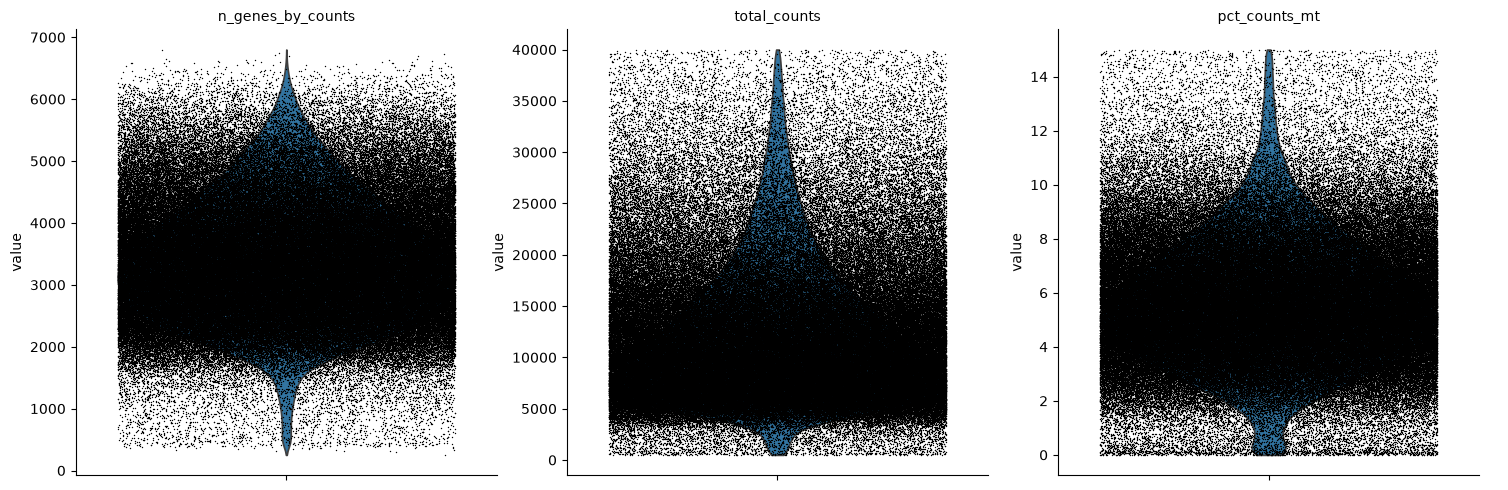

In [31]:
# Visualize QC metrics after low-count cell filtering
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

In [32]:
#Print the shape of the data 
adata.shape

(215364, 23711)

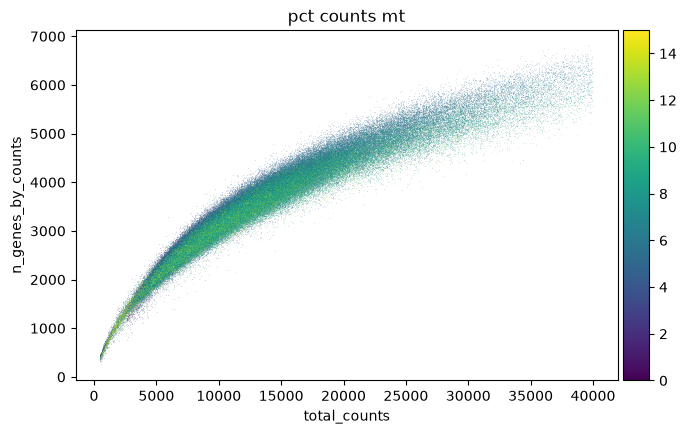

In [33]:
# Visualize counts vs. detected genes
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [34]:
# Save the data
adata_qc = adata.copy()
adata_qc.write("../data/frangieh/adata_qc.h5ad")

In [35]:
# Import package
import scanpy as sc 

In [36]:
#Load the data
adata = sc.read_h5ad("../data/frangieh/adata_qc.h5ad")

In [10]:
#Install required package
%pip install scrublet

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Detect doublets separately for each experimental condition using Scrublet
import scrublet as scr
import pandas as pd
import scipy.sparse as sp

# Get all experimental conditions
batches = adata.obs["condition"].cat.categories.tolist()
alldata = {}

# Run Scrublet separately for each condition
for batch in batches:
    tmp = adata[adata.obs["condition"] == batch].copy()
    print(batch, ":", tmp.shape[0], "cells")

    # Use raw count data
    X = tmp.raw.X if tmp.raw is not None else tmp.X

    # Detect doublets using 20 principal components
    scrub = scr.Scrublet(X)
    doublet_scores, predicted_doublets = scrub.scrub_doublets(
        verbose=False,
        n_prin_comps=20
    )

    # Store doublet scores and predictions
    alldata[batch] = pd.DataFrame(
        {
            "doublet_score": doublet_scores,
            "predicted_doublets": predicted_doublets
        },
        index=tmp.obs.index
    )

    print(predicted_doublets.sum(), "predicted doublets")

Co-culture : 73114 cells
8576 predicted doublets
Control : 57627 cells
7015 predicted doublets
IFNγ : 87590 cells


In [ ]:
# Add Scrublet doublet scores and predictions to the AnnData object
scrub_pred = pd.concat(alldata.values())
adata.obs['doublet_scores'] = scrub_pred['doublet_score'] 
adata.obs['predicted_doublets'] = scrub_pred['predicted_doublets'] 

# Count the total number of predicted doublets
sum(adata.obs['predicted_doublets'])

In [ ]:
# Convert doublet predictions to labels and compare gene counts between singlets and doublets
%matplotlib inline

adata.obs['doublet_info'] = adata.obs["predicted_doublets"].astype(str)

sc.pl.violin(
    adata,
    'n_genes_by_counts',
    jitter=0.4,
    groupby='doublet_info',
    rotation=45
)

In [43]:
# Save the data with the predicted doublet annotations
adata_qc_pd = adata.copy()
adata_qc_pd.write_h5ad("../data/frangieh/adata_pd.h5ad")

In [1]:
# Load the data 
import scanpy as sc
adata = sc.read_h5ad("../data/frangieh/adata_pd.h5ad")

In [3]:
# Remove the predicted doublets 
adata = adata[adata.obs['predicted_doublets'] == False].copy()
print(adata.shape)

(193858, 23711)


In [4]:
# To remove the perturbations in perturbation column represented less than 15 cells for each condition seperately
# Count cells for each perturbation in each condition
counts = (
    adata.obs
    .groupby(["perturbation", "condition"], observed=True)
    .size()
    .unstack(fill_value=0)
)

# Show perturbations with fewer than 15 cells in at least one condition
low_count_perturbations = counts[
    (counts < 15).any(axis=1)
]

print(low_count_perturbations)
print(
    "Perturbations with <15 cells in at least one condition:",
    len(low_count_perturbations)
)

condition     Co-culture  Control  IFNγ
perturbation                           
ATP1A1                10        7    22
CCT6A                 20       13    19
DNAJC9                 8       15    17
EIF2S3                14       14    17
PSMA7                 11        4    13
RACK1                  7        7    18
SNRPE                 10       10    19
SNRPF                 12       11    13
TUBB                   5        2     4
UBA52                 13        9    17
UBL5                   6        2     8
Perturbations with <15 cells in at least one condition: 11


In [5]:
# Keep perturbations represented by at least 15 cells
# in each experimental condition
valid_perturbations = counts[
    (counts >= 15).all(axis=1)
].index

adata = adata[
    adata.obs["perturbation"].isin(valid_perturbations)
].copy()

print("Remaining perturbations:", len(valid_perturbations))

Remaining perturbations: 238


In [6]:
#Save the data
adata_qc_done = adata.copy()
adata_qc_done.write_h5ad("../data/frangieh/adata_qc_done.h5ad")

In [7]:
# Load the qc done data
import scanpy as sc
adata = sc.read_h5ad("../data/frangieh/adata_qc_done.h5ad")

In [8]:
# Store the raw counts in a separate layer
adata.layers["counts"] = adata.X.copy()

In [9]:
# Normalize total counts per cell and log-transform the data
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [10]:
# Highly dynamical genes
sc.pp.highly_variable_genes(adata, n_top_genes=2000)

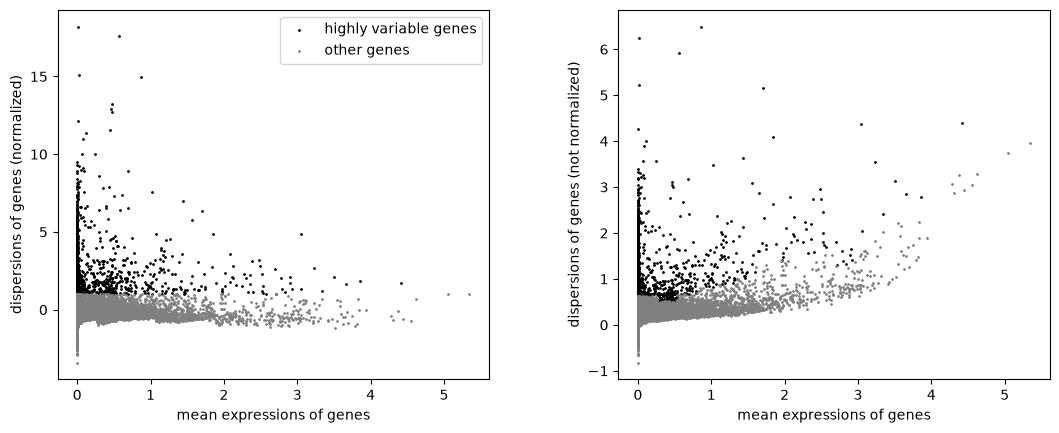

In [11]:
# Visualize the highly variable genes
sc.pl.highly_variable_genes(adata)

In [12]:
#Dimensionality reduction via PCA
sc.tl.pca(adata)

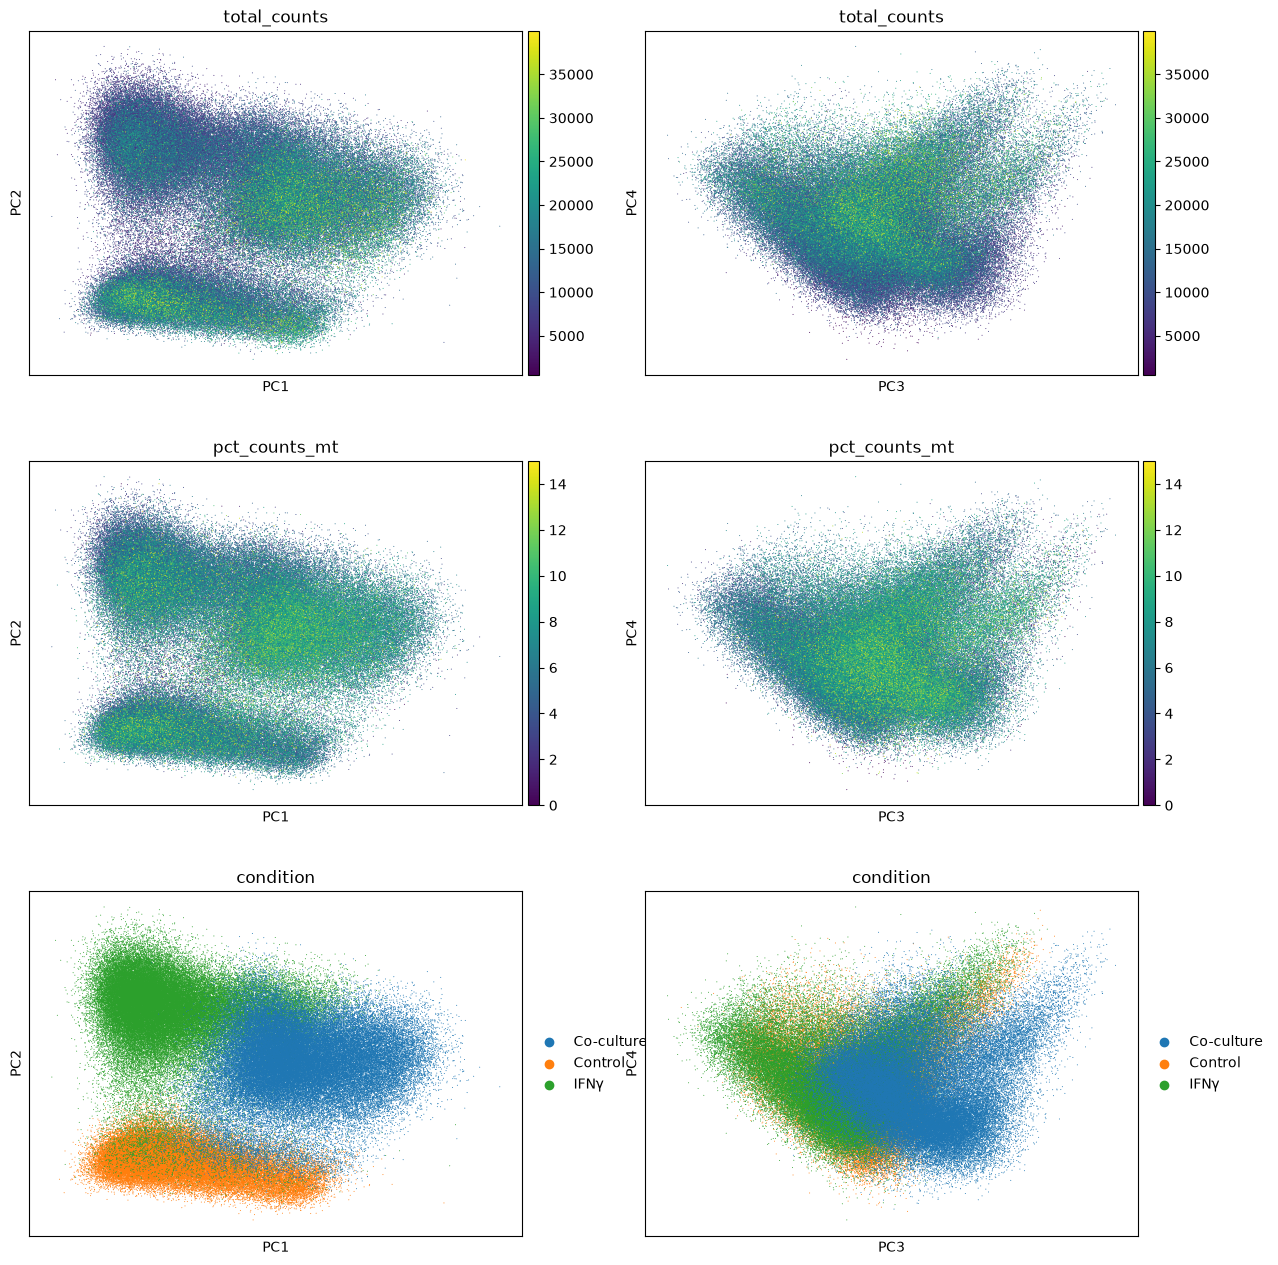

In [13]:
# Visualize PCA colored by QC metrics and experimental condition
sc.pl.pca(
    adata,
    color=["total_counts", "total_counts", "pct_counts_mt", "pct_counts_mt", "condition", "condition"],
    dimensions=[(0, 1), (2, 3), (0, 1), (2, 3), (0, 1), (2, 3)],
    ncols=2,
    size=2,
)

In [14]:
# Save the data
adata_hvg_qc = adata.copy()
adata_hvg_qc.write_h5ad("../data/frangieh/adata_hvg_qc.h5ad")